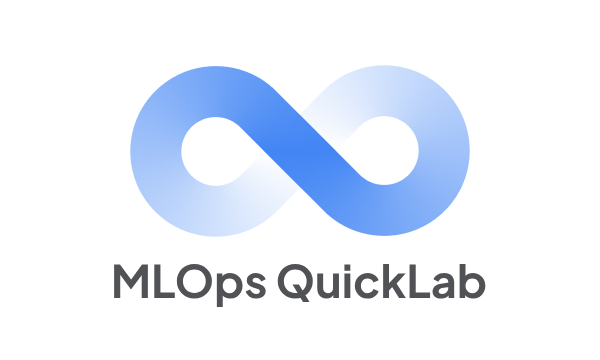

8. Vertex AI - 빅데이터를 이용한 파이프라인

In [1]:
!pip install -q -U google-cloud-aiplatform kfp google-cloud-pipeline-components

In [2]:
from google.cloud.aiplatform import gapic as aiplatform_gapic
from kfp.v2 import compiler
from kfp.v2.dsl import pipeline, component
from google.cloud import bigquery, storage, aiplatform
from google.oauth2 import service_account

/tmp/ipykernel_50089/1506054727.py:2: DeprecationWarning: The module `kfp.v2` is deprecated and will be removed in a futureversion. Please import directly from the `kfp` namespace, instead of `kfp.v2`.
  from kfp.v2 import compiler


In [3]:
# from google.colab import auth
# auth.authenticate_user()

In [4]:
credentials = service_account.Credentials.from_service_account_file("credentials.json")

In [5]:
!gcloud auth login --cred-file=credentials.json


You are running on a Google Compute Engine virtual machine.
It is recommended that you use service accounts for authentication.

You can run:

  $ gcloud config set account `ACCOUNT`

to switch accounts if necessary.

Your credentials may be visible to others with access to this
virtual machine. Are you sure you want to authenticate with
your personal account?

Do you want to continue (Y/n)?  Y


You are already authenticated with 
'mlops-quicklab@mlops-493303.iam.gserviceaccount.com'.
Do you wish to proceed and overwrite existing credentials?

Do you want to continue (Y/n)?  Y


Authenticated with service account credentials for: [mlops-quicklab@mlops-493303.iam.gserviceaccount.com].
Your current project is [mlops-493303].  You can change this setting by running:
  $ gcloud config set project PROJECT_ID


In [6]:
PROJECT_ID = "mlops-493303"                     # @param {type: "string"}
REGION = "asia-northeast3"                             # @param {type: "string"}
BUCKET_NAME = "mlops-quicklab-0422"                         # @param {type: "string"}
DATASET_ID = "example"                                 # @param {type: "string"}
TABLE_ID = "netflix_prize_data"                        # @param {type: "string"}

In [7]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

In [8]:
!pip install kaggle
!kaggle datasets download -d netflix-inc/netflix-prize-data
!unzip "netflix-prize-data.zip" -d netflix-prize-data

Dataset URL: https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data
License(s): other
100% 683M/683M [00:01<00:00, 381MB/s]

Archive:  netflix-prize-data.zip
  inflating: netflix-prize-data/README  
  inflating: netflix-prize-data/combined_data_1.txt  
  inflating: netflix-prize-data/combined_data_2.txt  
  inflating: netflix-prize-data/combined_data_3.txt  
  inflating: netflix-prize-data/combined_data_4.txt  
  inflating: netflix-prize-data/movie_titles.csv  
  inflating: netflix-prize-data/probe.txt  
  inflating: netflix-prize-data/qualifying.txt  


In [9]:
import pandas as pd
import numpy as np

data_dir = "netflix-prize-data"
files = [
    os.path.join(data_dir, f)
    for f in [
        "combined_data_1.txt",
        "combined_data_2.txt",
        "combined_data_3.txt",
        "combined_data_4.txt",
    ]
]
data = pd.DataFrame()

for file in files:
    df = pd.read_csv(file, header=None, names=["Cust_Id", "Rating", "Date"], usecols=[0, 1, 2])
    df["Rating"] = df["Rating"].astype(float)
    df["Movie_Id"] = (
        df["Cust_Id"]
        .apply(lambda x: x[:-1] if ":" in x else np.nan)
        .ffill()
        .astype(int)
    )
    df = df[df["Rating"].notna()]
    data = pd.concat([data, df])

In [10]:
storage_client = storage.Client(credentials=credentials)
bucket = storage_client.bucket(BUCKET_NAME)

In [11]:
aiplatform.init(project=PROJECT_ID, location=REGION, credentials=credentials)

In [12]:
def upload_blob(source_file_name: str, destination_blob_name: str) -> None:
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"File {source_file_name} uploaded to {destination_blob_name}.")

In [13]:
def load_to_bigquery(gcs_uri):
    bigquery_client = bigquery.Client(credentials=credentials)
    table_id = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}"
    job_config = bigquery.LoadJobConfig(
        schema=[
            bigquery.SchemaField("Cust_Id", "STRING"),
            bigquery.SchemaField("Rating", "FLOAT"),
            bigquery.SchemaField("Date", "STRING"),
            bigquery.SchemaField("Movie_Id", "INTEGER"),
        ],
        skip_leading_rows=1,
        source_format=bigquery.SourceFormat.CSV,
    )
    load_job = bigquery_client.load_table_from_uri(
        gcs_uri, table_id, job_config=job_config
    )

    load_job.result()
    print(f"Table {table_id} loaded to BigQuery.")

In [14]:
csv_file_name = "netflix_prize_data.csv"
data.to_csv(csv_file_name, index=False)
upload_blob(csv_file_name, csv_file_name)

File netflix_prize_data.csv uploaded to netflix_prize_data.csv.


In [15]:
load_to_bigquery(f"gs://{BUCKET_NAME}/{csv_file_name}")

Table mlops-493303.example.netflix_prize_data loaded to BigQuery.


In [16]:
PIPELINE_ROOT = f"gs://{BUCKET_NAME}/pipeline_root"
BUCKET_PATH = f"gs://{BUCKET_NAME}"
MODEL_DIR = f"{BUCKET_PATH}/model"
DATA_DIR = f"{BUCKET_PATH}/data"

In [17]:
DEPLOY_COMPUTE = "n1-standard-2"
DEPLOY_ACCELERATOR = "NVIDIA_TESLA_T4"

In [18]:
@component(base_image="python:3.11", packages_to_install=["google-cloud-bigquery"])
def export_data_to_gcs(
    project_id: str, dataset_id: str, table_id: str, gcs_bucket_path: str
) -> str:
    from google.cloud import bigquery

    client = bigquery.Client(project=project_id)
    destination_uri = f"{gcs_bucket_path}/netflix_data_*.csv"

    query = f"""
    EXPORT DATA OPTIONS(
        uri='{destination_uri}',
        format='CSV',
        overwrite=true
    ) AS
    SELECT *
    FROM `{project_id}.{dataset_id}.{table_id}`
    WHERE Cust_Id IN (
        SELECT Cust_Id
        FROM `{project_id}.{dataset_id}.{table_id}`
        GROUP BY Cust_Id
        HAVING MOD(FARM_FINGERPRINT(Cust_Id), 2000) = 0
    )
    """

    extract_job = client.query(query)
    extract_job.result()

    print(f"Sampled data exported directly to {destination_uri}")
    return destination_uri

In [19]:
@component(
    base_image="python:3.11",
    packages_to_install=[
        "torch",
        "torchvision",
        "numpy",
        "pandas",
        "gcsfs",
        "tqdm",
        "google-cloud-storage",
        "torch-model-archiver",
    ],
)
def train_model(project_id: str, gcs_bucket_name: str, gcs_bucket_path: str, data_path: str) -> str:
    from google.cloud import storage
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import torch.nn.functional as F
    import pandas as pd
    import numpy as np
    import gcsfs
    import math
    from tqdm import tqdm
    from torch.utils.data import DataLoader, Dataset
    import os
    import subprocess

    class NetflixDataset(Dataset):
        def __init__(self, data: pd.DataFrame, seq_len: int = 10):
            """
            data: Cust_Id, Movie_Id, Rating, Date 등의 열을 가진 DataFrame
            seq_len: 시퀀스 길이
            """
            self.seq_len = seq_len
            # 유저별 데이터 그룹핑 후 시퀀스 생성
            self.data = data.groupby("Cust_Id").apply(self._create_sequences).reset_index(drop=True)

        def __len__(self) -> int:
            return len(self.data)

        def _create_sequences(self, user_data: pd.DataFrame) -> pd.DataFrame:
            # 날짜 기준으로 정렬
            user_data = user_data.sort_values(by="Date")

            # i:i+seq_len 윈도우로 Movie_Id, Rating을 시퀀스로 구성
            sequences = [
                (
                    user_data["Movie_Id"].values[i:i+self.seq_len],
                    user_data["Rating"].values[i:i+self.seq_len],
                )
                for i in range(len(user_data) - self.seq_len + 1)  # seq_len 길이를 만족하는 마지막 인덱스까지
            ]

            return pd.DataFrame(sequences, columns=["Movie_Sequence", "Rating_Sequence"])

        def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
            movies = torch.tensor(self.data.iloc[idx]["Movie_Sequence"], dtype=torch.long)
            ratings = torch.tensor(self.data.iloc[idx]["Rating_Sequence"], dtype=torch.float)

            return movies, ratings

    class SinusoidalPositionalEncoding(nn.Module):
        def __init__(self, emb_size: int, max_len: int = 5000):
            super(SinusoidalPositionalEncoding, self).__init__()
            # pos: [0 ... max_len-1]
            position = torch.arange(max_len).unsqueeze(1)
            # div_term: 각 차원별 주기를 달리하기 위한 분모
            div_term = torch.exp(torch.arange(0, emb_size, 2) * (-math.log(10000.0) / emb_size))

            # pos_embedding: (max_len, emb_size)
            pos_embedding = torch.zeros(max_len, emb_size)
            pos_embedding[:, 0::2] = torch.sin(position * div_term)
            pos_embedding[:, 1::2] = torch.cos(position * div_term)

            self.register_buffer('pos_embedding', pos_embedding)  # 학습 X, 등록된 텐서

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            # x: (batch_size, seq_len, emb_size)
            seq_len = x.size(1)
            # pos_embedding 중 seq_len 길이에 해당하는 부분만 사용
            return x + self.pos_embedding[:seq_len, :]


    class RecommendationNetwork(nn.Module):
        def __init__(
            self,
            num_movies: int,
            emb_size: int = 100,
            nhead: int = 4,
            num_layers: int = 2,
            dim_feedforward: int = 512,
            max_seq_len: int = 5000  # 가변 시퀀스 길이 지원을 위해 충분히 큰 값 설정
        ):
            super(RecommendationNetwork, self).__init__()

            self.movie_emb = nn.Embedding(num_movies + 1, emb_size)
            self.pos_encoder = SinusoidalPositionalEncoding(emb_size, max_len=max_seq_len)

            encoder_layer = nn.TransformerEncoderLayer(
                d_model=emb_size,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                batch_first=True
            )
            self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            self.fc = nn.Linear(emb_size, 1)

        def forward(self, movies: torch.Tensor) -> torch.Tensor:
            """
            movies: (batch_size, seq_len)
            seq_len이 가변적이어도 positional encoding을 매번 해당 길이에 맞춰 계산 가능
            """
            batch_size, seq_len = movies.size()

            embedded = self.movie_emb(movies)  # (batch_size, seq_len, emb_size)
            pos_encoded = self.pos_encoder(embedded)  # (batch_size, seq_len, emb_size)

            transformer_out = self.transformer_encoder(pos_encoded)  # (batch_size, seq_len, emb_size)
            preds = self.fc(transformer_out[:, -1, :])  # (batch_size, 1)

            return preds.squeeze(1)  # (batch_size,)


    def calculate_accuracy(y_pred, y_true):
        y_pred_rounded = torch.round(y_pred)
        correct_predictions = (y_pred_rounded == y_true).float().sum()
        accuracy = correct_predictions / y_true.shape[0]
        return accuracy.item()


    client = storage.Client()
    fs = gcsfs.GCSFileSystem(project=project_id)
    files = fs.glob(data_path)
    data = pd.concat([
        pd.read_csv(
            fs.open(file_),
            header=None,
            names=["Cust_Id", "Rating", "Date", "Movie_Id"],
            dtype={
                "Cust_Id": "int32",
                "Rating": "float32",
                "Date": "string",
                "Movie_Id": "int32"
            }
        )
        for file_ in files
    ], ignore_index=True)
    num_movies = data["Movie_Id"].max()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = RecommendationNetwork(num_movies=num_movies, emb_size=100).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    dataset = NetflixDataset(data)
    data_loader = DataLoader(dataset, batch_size=512, shuffle=True)

    loss_values: list[float] = []
    accuracy_values: list[float] = []
    num_epochs = 5

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        total_accuracy = 0.0
        count_batches = 0

        for movies, ratings in tqdm(data_loader):
            movies = movies.to(device)     # (batch_size, seq_len)
            ratings = ratings.to(device)   # (batch_size, seq_len)

            # 마지막 영화에 대한 평점 예측을 목표로 한다고 가정
            target = ratings[:, -1]  # 시퀀스의 마지막 평점을 타겟으로
            optimizer.zero_grad()
            outputs = model(movies)  # (batch_size,)

            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()

            accuracy = calculate_accuracy(outputs, target)
            total_loss += loss.item()
            total_accuracy += accuracy
            count_batches += 1

        avg_loss = total_loss / count_batches
        avg_accuracy = total_accuracy / count_batches
        loss_values.append(avg_loss)
        accuracy_values.append(avg_accuracy)
        print(f"Epoch {epoch+1}: Loss = {avg_loss}, Accuracy = {avg_accuracy}")

    torch.save(model.state_dict(), "model.pth")
    with open("model.py", "w") as f:
        f.write('''
import torch
import torch.nn as nn
import math

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, max_len: int = 5000):
        super(SinusoidalPositionalEncoding, self).__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, emb_size, 2) * (-math.log(10000.0) / emb_size))
        pos_embedding = torch.zeros(max_len, emb_size)
        pos_embedding[:, 0::2] = torch.sin(position * div_term)
        pos_embedding[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pos_embedding', pos_embedding)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seq_len = x.size(1)
        return x + self.pos_embedding[:seq_len, :]

class RecommendationNetwork(nn.Module):
    def __init__(self, num_movies: int, emb_size: int = 100, nhead: int = 4, num_layers: int = 2, dim_feedforward: int = 512, max_seq_len: int = 5000):
        super(RecommendationNetwork, self).__init__()
        self.movie_emb = nn.Embedding(num_movies + 1, emb_size)
        self.pos_encoder = SinusoidalPositionalEncoding(emb_size, max_len=max_seq_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_size, nhead=nhead, dim_feedforward=dim_feedforward, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(emb_size, 1)

    def forward(self, movies: torch.Tensor) -> torch.Tensor:
        embedded = self.movie_emb(movies)
        pos_encoded = self.pos_encoder(embedded)
        transformer_out = self.transformer_encoder(pos_encoded)
        preds = self.fc(transformer_out[:, -1, :])
        return preds.squeeze(1)
        ''')

    # handler.py 파일 저장
    with open("handler.py", "w") as f:
        f.write('''
import torch
from model import RecommendationNetwork

def model_fn(model_dir):
    num_movies = 17770  # 데이터셋에 따른 값
    model = RecommendationNetwork(num_movies)
    model.load_state_dict(torch.load(f"{model_dir}/model.pth"))
    model.eval()
    return model

def predict_fn(input_data, model):
    with torch.no_grad():
        predictions = model(input_data)
    return predictions
        ''')

    # Torch Model Archiver 실행
    subprocess.run([
        "torch-model-archiver",
        "--model-name", "model",
        "--version", "1.0",
        "--model-file", "model.py",
        "--serialized-file", "model.pth",
        "--handler", "handler.py",
        "--export-path", ".",
        "--force"
    ])

    # .mar 파일 업로드
    bucket = client.bucket(gcs_bucket_name)
    blob = bucket.blob(f"models/model.mar")
    blob.upload_from_filename("model.mar")
    print("Model archive has been uploaded.")

    return f"gs://{gcs_bucket_name}/models"

In [21]:
# data_path

In [22]:
@component(base_image="python:3.11", packages_to_install=["google-cloud-aiplatform"])
def deploy_model_op(project_id: str, model_path: str):
    from google.cloud import aiplatform

    DEPLOY_COMPUTE = "n1-standard-2"
    DEPLOY_ACCELERATOR = "NVIDIA_TESLA_T4"

    model = aiplatform.Model.upload(
        project=project_id,
        display_name="netflix-recommender",
        artifact_uri=model_path,
        serving_container_image_uri="asia-northeast3-docker.pkg.dev/mlops-493303/mlops-quicklab/trainer:1.0.0",
    )
    endpoint = model.deploy(
        machine_type=DEPLOY_COMPUTE,
        min_replica_count=1,
        max_replica_count=1,
        accelerator_type=DEPLOY_ACCELERATOR,
        accelerator_count=1,
        traffic_percentage=100,
    )

In [23]:
@pipeline(name="netflix-recommender-pipeline", pipeline_root=PIPELINE_ROOT)
def netflix_recommender_pipeline(
    project_id: str,
    dataset_id: str,
    table_id: str,
    gcs_bucket_name: str,
    gcs_bucket_path: str
):
    export_op = export_data_to_gcs(
        project_id=project_id,
        dataset_id=dataset_id,
        table_id=table_id,
        gcs_bucket_path=gcs_bucket_path
    )
    train_op = (
        train_model(
            project_id=project_id,
            gcs_bucket_name=gcs_bucket_name,
            gcs_bucket_path=gcs_bucket_path,
            data_path=export_op.output,
        )
        .set_memory_limit("32Gi")
        # Training 머신에 대한 Quota 존재시 아래 주석 해제
        # .add_node_selector_constraint(DEPLOY_ACCELERATOR)
    )
    deploy_model_op(project_id=project_id, model_path=train_op.output)

In [24]:
compiler.Compiler().compile(
    pipeline_func=netflix_recommender_pipeline,
    package_path="pipeline_job.yaml",
)

job = aiplatform.PipelineJob(
    display_name="netflix_recommender_pipeline",
    template_path="pipeline_job.yaml",
    pipeline_root=PIPELINE_ROOT,
    parameter_values={
        "project_id": PROJECT_ID,
        "dataset_id": DATASET_ID,
        "table_id": TABLE_ID,
        "gcs_bucket_name": BUCKET_NAME,
        "gcs_bucket_path": f"{BUCKET_PATH}/datasets/netflix_prize_data",
    },
)
job.submit(
    service_account=f"mlops-quicklab@{PROJECT_ID}.iam.gserviceaccount.com"
)